# Statisitsche Auswertung des Teilexperiment A

### Preprocessing

In [666]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
import os
import json
import sys

In [667]:
RESULTS_DIR = "../results/"
TABLES_DIR = "./tables/"
FIGURES_DIR = "./figures/"

for directory in [TABLES_DIR, FIGURES_DIR]:
    os.makedirs(directory, exist_ok=True)

In [668]:
def load_and_preprocess_data(filepath):
    df = pd.read_csv(filepath)
    df["all_tokens"] = df["all_tokens"].fillna(df["input_tokens"] + df["output_tokens"])
    return df

In [669]:
df_A_gemini = load_and_preprocess_data("../results/experiment_benchmark_A_all_20260708_144919.csv")

df_A_gemini.head()

,condition,complexity,doc_id,f1_exact,prec_exact,rec_exact,f1_substring,prec_substring,rec_substring,f1_fuzzy,...,all_tokens,retries_used,duration_seconds,match_results_fields,match_results_line_items,ground_truth,predicted,model,status,error_message
0,C1,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0.6667,0.6667,0.6667,0.6667,0.6667,0.6667,0.8000,...,0.0,0,0.001,"{""advertiser"": {""exact"": ""FN"", ""substring"": ""F...","{""exact"": {""tp"": 5, ""fp"": 0, ""fn"": 0}, ""substr...","{""advertiser"": ""Friends of Jeff Sessions Senat...","{""advertiser"": """", ""agency"": ""BRD 5126/ECR2680...",gemini-2.5-flash,OK,NaN
1,C2,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0.6667,0.5000,1.0000,0.6667,0.5000,1.0000,0.8000,...,2414.0,0,4.110,"{""advertiser"": {""exact"": ""FP_EXTRACTION_ERROR""...","{""exact"": {""tp"": 5, ""fp"": 0, ""fn"": 0}, ""substr...","{""advertiser"": ""Friends of Jeff Sessions Senat...","{""line_items"": [{""program_start_date"": ""02/26/...",gemini-2.5-flash,OK,NaN
2,C3,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0.8571,0.7500,1.0000,0.8571,0.7500,1.0000,0.8571,...,6815.0,0,7.453,"{""advertiser"": {""exact"": ""TP"", ""substring"": ""T...","{""exact"": {""tp"": 5, ""fp"": 0, ""fn"": 0}, ""substr...","{""advertiser"": ""Friends of Jeff Sessions Senat...","{""line_items"": [{""program_start_date"": ""02/26/...",gemini-2.5-flash,OK,NaN
3,C4,L1,0ea66228-6efd-8386-8000-e2e0c72e3825.pdf,0.4000,0.5000,0.3333,0.5000,0.6667,0.4000,0.4000,...,410332.0,3,1027.647,"{""advertiser"": {""exact"": ""TP"", ""substring"": ""T...","{""exact"": {""tp"": 0, ""fp"": 0, ""fn"": 5}, ""substr...","{""advertiser"": ""Friends of Jeff Sessions Senat...","{""line_items"": [], ""advertiser"": ""Friends of J...",gemini-2.5-flash,OK,NaN
4,C1,L1,63ad699d-fa76-17bb-1bc5-ab2fafd0a2a3.pdf,0.1176,0.1111,0.1250,0.2222,0.2222,0.2222,0.2222,...,0.0,0,0.002,"{""advertiser"": {""exact"": ""FP_EXTRACTION_ERROR""...","{""exact"": {""tp"": 0, ""fp"": 4, ""fn"": 3}, ""substr...","{""contract_num"": ""4339717"", ""flight_from"": ""05...","{""advertiser"": ""Entered By Grand Total: 4 $900...",gemini-2.5-flash,OK,NaN


In [670]:
df_A_gemini.columns

Index(['condition', 'complexity', 'doc_id', 'f1_exact', 'prec_exact',
       'rec_exact', 'f1_substring', 'prec_substring', 'rec_substring',
       'f1_fuzzy', 'prec_fuzzy', 'rec_fuzzy', 'is_hallucination',
       'is_numeric_hallucination', 'is_text_hallucination', 'input_tokens',
       'output_tokens', 'all_tokens', 'retries_used', 'duration_seconds',
       'match_results_fields', 'match_results_line_items', 'ground_truth',
       'predicted', 'model', 'status', 'error_message'],
      dtype='str')

In [671]:
df_A_gemini.status.value_counts()

status
OK    300
Name: count, dtype: int64

## Deskreptive Statsitik

### Funktionen

In [672]:
def export_summary_table(df, group_cols, metrics, filename):
    summary = df.groupby(group_cols)[metrics].agg(["mean", "median", "std"])

    formatted_summary = pd.DataFrame(index=summary.index)
    for metric in metrics:
        m = summary[metric]["mean"]
        s = summary[metric]["std"]
        mdn = summary[metric]["median"]

        formatted_summary[f"{metric}_M_SD"] = [
            f"{m_val:.3f} ({s_val:.3f})" for m_val, s_val in zip(m, s)
        ]
        formatted_summary[f"{metric}_Mdn"] = mdn.values

    formatted_summary.to_excel(os.path.join(TABLES_DIR, filename), index=True)
    return formatted_summary

In [673]:
def plot_metric_by_complexity(df, y_metric, ylabel, filename, plot_type="bar"):
    fig, ax = plt.subplots(figsize=(10, 6))

    if plot_type == "bar":
        sns.barplot(
            data=df,
            x="complexity",
            y=y_metric,
            hue="condition",
            ax=ax,
            palette="Blues_d",
            errorbar=None,
        )
    elif plot_type == "violin":
        df_plot = (
            df[df["condition"] != "C1"]
            if "token" in y_metric or "duration" in y_metric
            else df
        )
        sns.boxplot(
            data=df_plot,
            x="complexity",
            y=y_metric,
            hue="condition",
            ax=ax,
            cut=0,
        )

    ax.set_xlabel("Komplexitätsstufe (L1-L3)", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_DIR, filename))
    plt.close(fig)

### F1 Score, Recall und Precision

In [674]:
aggs = ["mean", "median", "std"]

In [675]:
f1_metrics = [
    "f1_exact",
    "prec_exact",
    "rec_exact",
    "f1_fuzzy",
    "prec_fuzzy",
    "rec_fuzzy",
    "f1_substring",
    "prec_substring",
    "rec_substring",
]

metrics_table = df_A_gemini.groupby("complexity")[f1_metrics].agg(aggs)

metrics_table.columns = [f"{col}_{stat}" for col, stat in metrics_table.columns]

# Tabelle abrunden für bessere Lesbarkeit
metrics_table = metrics_table.round(4)
display(metrics_table)

,f1_exact_mean,f1_exact_median,f1_exact_std,prec_exact_mean,prec_exact_median,prec_exact_std,rec_exact_mean,rec_exact_median,rec_exact_std,f1_fuzzy_mean,...,rec_fuzzy_std,f1_substring_mean,f1_substring_median,f1_substring_std,prec_substring_mean,prec_substring_median,prec_substring_std,rec_substring_mean,rec_substring_median,rec_substring_std
complexity,,,,,,,,,,,,,,,,,,,,,
L1,0.5816,0.6667,0.2633,0.5507,0.6000,0.2483,0.6394,0.7000,0.2946,0.6344,...,0.2912,0.6431,0.7059,0.2434,0.6338,0.7143,0.2387,0.6890,0.7136,0.2764
L2,0.2639,0.1791,0.2759,0.2335,0.1521,0.2410,0.3222,0.2222,0.3433,0.3465,...,0.3725,0.4539,0.5728,0.3403,0.4023,0.4286,0.3084,0.5528,0.7687,0.4132
L3,0.1626,0.0204,0.2912,0.1515,0.0197,0.2689,0.1843,0.0204,0.3291,0.2046,...,0.3538,0.2668,0.0359,0.3710,0.2466,0.0351,0.3409,0.3002,0.0342,0.4158


In [676]:
metrics_table_large = df_A_gemini.groupby(["complexity", "condition"])[f1_metrics].agg(
    aggs
)

metrics_table_large = metrics_table_large.sort_index(axis=1)

metrics_table_large = metrics_table_large.round(4)

display(metrics_table_large)

f1_exact                 f1_fuzzy                  \
                         mean  median     std     mean  median     std   
complexity condition                                                     
L1         C1          0.2499  0.2500  0.1496   0.3076  0.3077  0.1895   
           C2          0.6876  0.6667  0.2069   0.7607  0.8000  0.1653   
           C3          0.7002  0.6957  0.1902   0.7681  0.7692  0.1675   
           C4          0.6886  0.7143  0.1780   0.7012  0.7273  0.1826   
L2         C1          0.0426  0.0357  0.0449   0.0627  0.0571  0.0695   
           C2          0.3240  0.2667  0.2665   0.4737  0.4889  0.2593   
           C3          0.3401  0.2273  0.2612   0.4636  0.5294  0.2655   
           C4          0.3489  0.2222  0.3232   0.3861  0.2222  0.3512   
L3         C1          0.0126  0.0000  0.0251   0.0133  0.0000  0.0255   
           C2          0.2966  0.0656  0.3513   0.3505  0.1842  0.3558   
           C3          0.2351  0.0588  0.3436   0.3225  0.1842  0.3530   
           C4          0.1063  0.0000  0.2384   0.1320  0.0000  0.2694   

                     f1_substring                 prec_exact  ...  \
                             mean  median     std       mean  ...   
complexity condition                                          ...   
L1         C1              0.3560  0.3333  0.1741     0.2582  ...   
           C2              0.7307  0.7619  0.2100     0.6193  ...   
           C3              0.7552  0.7692  0.1512     0.6383  ...   
           C4              0.7305  0.7500  0.1794     0.6869  ...   
L2         C1              0.0471  0.0571  0.0460     0.0413  ...   
           C2              0.6718  0.7500  0.2314     0.2770  ...   
           C3              0.6042  0.6875  0.2532     0.2872  ...   
           C4              0.4924  0.6364  0.3331     0.3284  ...   
L3         C1              0.0146  0.0000  0.0256     0.0122  ...   
           C2              0.4520  0.5200  0.3923     0.2669  ...   
           C3              0.4405  0.5200  0.4087     0.2210  ...   
           C4              0.1603  0.0000  0.3178     0.1058  ...   

                     prec_substring rec_exact                 rec_fuzzy  \
                                std      mean  median     std      mean   
complexity condition                                                      
L1         C1                0.2777    0.2665  0.2857  0.1545    0.3121   
           C2                0.2066    0.7866  0.8333  0.2119    0.8646   
           C3                0.1600    0.7873  0.8000  0.1929    0.8567   
           C4                0.1577    0.7172  0.7500  0.2358    0.7216   
L2         C1                0.0462    0.0496  0.0385  0.0540    0.0696   
           C2                0.2325    0.4015  0.3125  0.3358    0.5846   
           C3                0.2471    0.4271  0.3000  0.3301    0.5812   
           C4                0.2995    0.4106  0.2727  0.3973    0.4485   
L3         C1                0.0235    0.0139  0.0000  0.0307    0.0146   
           C2                0.3610    0.3510  0.0714  0.4086    0.4135   
           C3                0.3812    0.2550  0.0714  0.3682    0.3551   
           C4                0.2908    0.1175  0.0000  0.2726    0.1484   

                                     rec_substring                  
                      median     std          mean  median     std  
complexity condition                                                
L1         C1         0.2857  0.1852        0.3471  0.3333  0.1488  
           C2         0.9000  0.1621        0.8170  0.8889  0.2180  
           C3         0.9000  0.1524        0.8504  0.8889  0.1460  
           C4         0.7500  0.2356        0.7415  0.8000  0.2354  
L2         C1         0.0588  0.0762        0.0546  0.0500  0.0550  
           C2         0.5714  0.3160        0.8206  0.9000  0.2582  
           C3         0.6667  0.3299        0.7469  0.8333  0.2911  
           C4         0.3000  0.4169        0.5892  0.8235

In [677]:
export_summary_table(
    df_A_gemini, ["condition", "complexity"], f1_metrics, "f1_precision_recall_summary.xlsx"
)

f1_exact_M_SD  f1_exact_Mdn prec_exact_M_SD  \
condition complexity                                                
C1        L1          0.250 (0.150)        0.2500   0.258 (0.173)   
          L2          0.043 (0.045)        0.0357   0.041 (0.046)   
          L3          0.013 (0.025)        0.0000   0.012 (0.023)   
C2        L1          0.688 (0.207)        0.6667   0.619 (0.207)   
          L2          0.324 (0.267)        0.2667   0.277 (0.224)   
          L3          0.297 (0.351)        0.0656   0.267 (0.325)   
C3        L1          0.700 (0.190)        0.6957   0.638 (0.189)   
          L2          0.340 (0.261)        0.2273   0.287 (0.219)   
          L3          0.235 (0.344)        0.0588   0.221 (0.326)   
C4        L1          0.689 (0.178)        0.7143   0.687 (0.157)   
          L2          0.349 (0.323)        0.2222   0.328 (0.294)   
          L3          0.106 (0.238)        0.0000   0.106 (0.212)   

                      prec_exact_Mdn rec_exact_M_SD  rec_exact_Mdn  \
condition complexity                                                 
C1        L1                  0.2500  0.266 (0.155)         0.2857   
          L2                  0.0278  0.050 (0.054)         0.0385   
          L3                  0.0000  0.014 (0.031)         0.0000   
C2        L1                  0.6000  0.787 (0.212)         0.8333   
          L2                  0.2500  0.401 (0.336)         0.3125   
          L3                  0.0606  0.351 (0.409)         0.0714   
C3        L1                  0.6364  0.787 (0.193)         0.8000   
          L2                  0.1923  0.427 (0.330)         0.3000   
          L3                  0.0500  0.255 (0.368)         0.0714   
C4        L1                  0.7143  0.717 (0.236)         0.7500   
          L2                  0.2609  0.411 (0.397)         0.2727   
          L3                  0.0000  0.118 (0.273)         0.0000   

                      f1_fuzzy_M_SD  f1_fuzzy_Mdn prec_fuzzy_M_SD  \
condition complexity                                                
C1        L1          0.308 (0.190)        0.3077   0.329 (0.225)   
          L2          0.063 (0.069)        0.0571   0.070 (0.117)   
          L3          0.013 (0.025)        0.0000   0.013 (0.023)   
C2        L1          0.761 (0.165)        0.8000   0.693 (0.177)   
          L2          0.474 (0.259)        0.4889   0.408 (0.231)   
          L3          0.351 (0.356)        0.1842   0.315 (0.330)   
C3        L1          0.768 (0.168)        0.7692   0.709 (0.179)   
          L2          0.464 (0.266)        0.5294   0.396 (0.233)   
          L3          0.323 (0.353)        0.1842   0.300 (0.334)   
C4        L1          0.701 (0.183)        0.7273   0.707 (0.167)   
          L2          0.386 (0.351)        0.2222   0.365 (0.324)   
          L3          0.132 (0.269)        0.0000   0.128 (0.239)   

                      prec_fuzzy_Mdn rec_fuzzy_M_SD  rec_fuzzy_Mdn  \
condition complexity                                                 
C1        L1                  0.2857  0.312 (0.185)         0.2857   
          L2                  0.0556  0.070 (0.076)         0.0588   
          L3                  0.0000  0.015 (0.031)         0.0000   
C2        L1                  0.7143  0.865 (0.162)         0.9000   
          L2                  0.4545  0.585 (0.316)         0.5714   
          L3                  0.1707  0.413 (0.412)         0.2105   
C3        L1                  0.7500  0.857 (0.152)         0.9000   
          L2                  0.4545  0.581 (0.330)         0.6667   
          L3                  0.1707  0.355 (0.380)         0.2000   
C4        L1                  0.7143  0.722 (0.236)         0.7500   
          L2                  0.3750  0.448 (0.417)         0.3000   
          L3                  0.0000  0.148 (0.309)         0.0000   

                     f1_substring_M_SD  f1_substring_Mdn prec_substring_M_SD  \
condition complexity                          

In [678]:
# overall f1_exact plot
plot_metric_by_complexity(
    df_A_gemini, "f1_exact", "F1 Exact Score", "f1_exact_bar.png", plot_type="bar"
)

In [ ]:

metrics = [
    "prec_exact",
    "rec_exact",
    "f1_substring",
    "prec_substring",
    "rec_substring",
    "f1_fuzzy",
    "prec_fuzzy",
    "rec_fuzzy",
    "is_hallucination",
    "is_numeric_hallucination",
    "is_text_hallucination",
    "input_tokens",
    "output_tokens",
    "all_tokens",
    "duration_seconds",
]

for metric in metrics:
    plot_metric_by_complexity(df_A_gemini, metric, f"{metric} Score0", f"{metric}_bar.png", plot_type="bar")

In [680]:
f1_data = metrics_table_large["f1_exact"][["mean", "std"]]

f1_data_formatted = f1_data.apply(
    lambda row: f"{row['mean']:.3f} ({row['std']:.3f})", axis=1
)

df_result = f1_data_formatted.unstack(level="complexity")

total = df_A_gemini.groupby("condition")["f1_exact"].agg(["mean", "std"])
df_result["Total"] = total.apply(
    lambda row: f"{row['mean']:.3f} ({row['std']:.3f})", axis=1
)

df_result = df_result[["L1", "L2", "L3", "Total"]]
df_result.index = [
    "C1: RPA",
    "C2: Single-Prompt",
    "C3: Single-Agent",
    "C4: Multi-Agent",
]

display(df_result)
df_result.to_excel("./tables/f1_exact_summary.xlsx", index=True)

complexity,L1,L2,L3,Total
C1: RPA,0.250 (0.150),0.043 (0.045),0.013 (0.025),0.102 (0.139)
C2: Single-Prompt,0.688 (0.207),0.324 (0.267),0.297 (0.351),0.436 (0.330)
C3: Single-Agent,0.700 (0.190),0.340 (0.261),0.235 (0.344),0.425 (0.335)
C4: Multi-Agent,0.689 (0.178),0.349 (0.323),0.106 (0.238),0.381 (0.347)


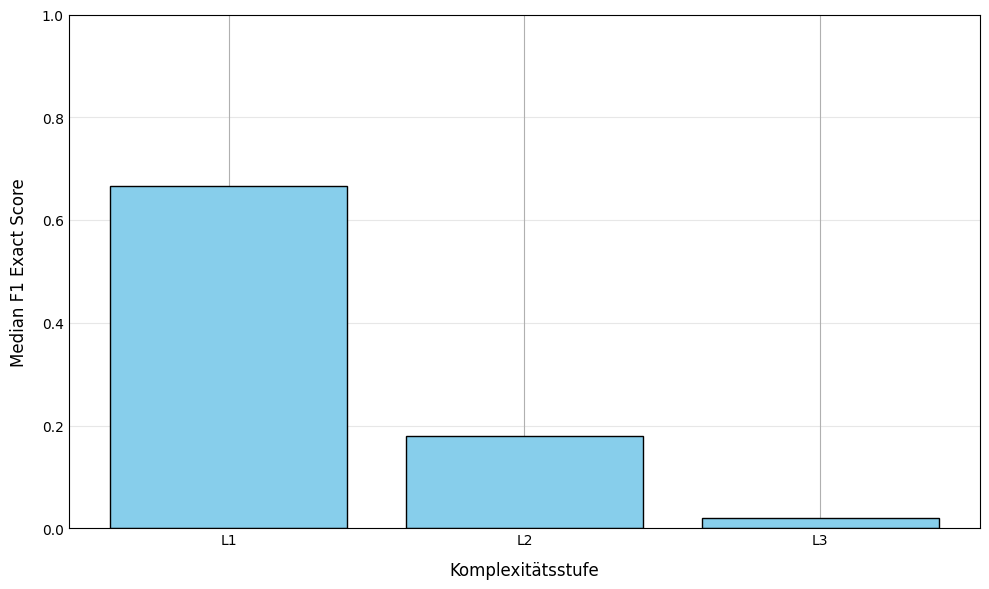

In [681]:
median_scores = df_A_gemini.groupby("complexity")["f1_exact"].median()

labels = median_scores.index.tolist()
medians = median_scores.values

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(labels, medians, color="skyblue", edgecolor="black")

ax.set_xlabel("Komplexitätsstufe", fontsize=12, labelpad=10)
ax.set_ylabel("Median F1 Exact Score", fontsize=12, labelpad=10)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("./figures/f1_exact_bar_chart_overall.png")
plt.show()

In [682]:
prec_recall_exact = df_A_gemini.groupby(["complexity", "condition"])[["prec_exact", "rec_exact"]].agg(["mean", "std"])

prec_recall_exact_formatted = pd.DataFrame()

for metric in ["prec_exact", "rec_exact"]:
    formatted = prec_recall_exact[metric].apply(
        lambda row: f"{row['mean']:.3f} ({row['std']:.3f})", axis=1
    )
    prec_recall_exact_formatted[metric] = formatted

prec_recall_table = prec_recall_exact_formatted.unstack(level="complexity")
prec_recall_table = prec_recall_table.swaplevel(axis=1).sort_index(axis=1)

prec_recall_table.index = [
    "C1: RPA",
    "C2: Single-Prompt",
    "C3: Single-Agent",
    "C4: Multi-Agent",
]

display(prec_recall_table)

prec_recall_table.to_excel("./tables/precision_recall_summary.xlsx", index=True)

complexity                    L1                            L2                 \
                      prec_exact      rec_exact     prec_exact      rec_exact   
C1: RPA            0.258 (0.173)  0.266 (0.155)  0.041 (0.046)  0.050 (0.054)   
C2: Single-Prompt  0.619 (0.207)  0.787 (0.212)  0.277 (0.224)  0.401 (0.336)   
C3: Single-Agent   0.638 (0.189)  0.787 (0.193)  0.287 (0.219)  0.427 (0.330)   
C4: Multi-Agent    0.687 (0.157)  0.717 (0.236)  0.328 (0.294)  0.411 (0.397)   

complexity                    L3                 
                      prec_exact      rec_exact  
C1: RPA            0.012 (0.023)  0.014 (0.031)  
C2: Single-Prompt  0.267 (0.325)  0.351 (0.409)  
C3: Single-Agent   0.221 (0.326)  0.255 (0.368)  
C4: Multi-Agent    0.106 (0.212)  0.118 (0.273)

In [690]:
df_filtered_C1 = df_A_gemini[df_A_gemini["condition"] != "C1"]

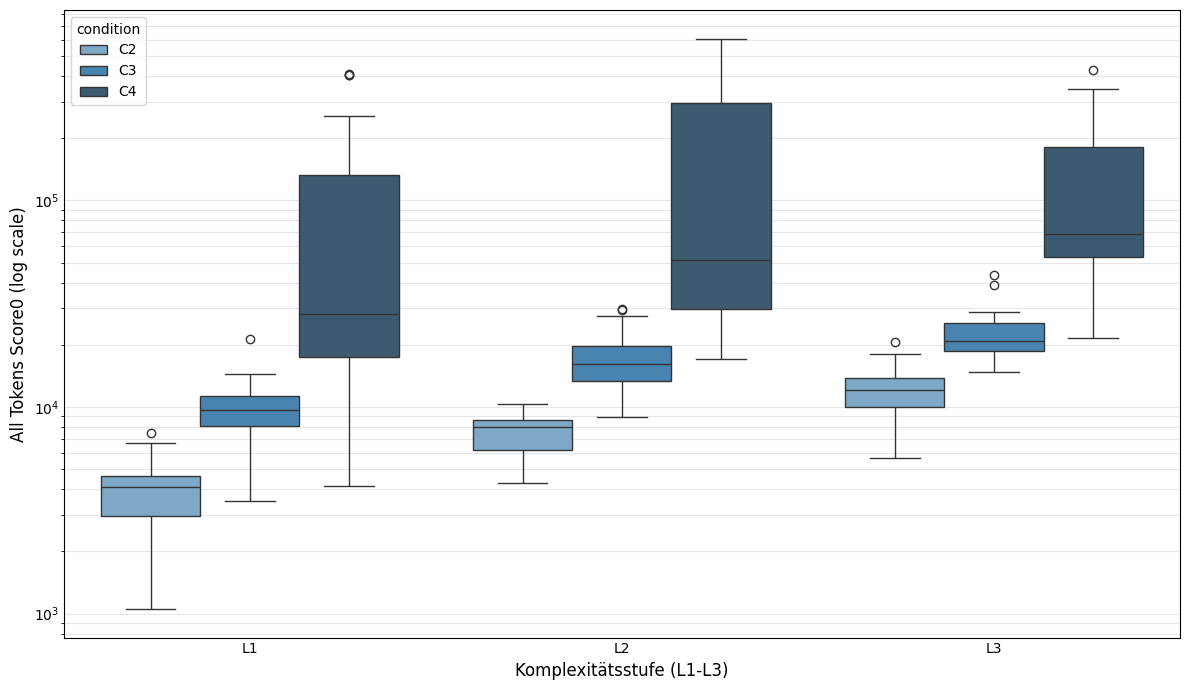

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.boxplot(
    data=df_filtered_C1,
    x="complexity",
    y="all_tokens",
    hue="condition",
    ax=ax,
    palette="Blues_d",
)

# Logarithmische Skalierung aktivieren
ax.set_yscale("log")

# Achsen und Grid sauber formatieren
ax.set_xlabel("Komplexitätsstufe (L1-L3)", fontsize=12)
ax.set_ylabel("Gesamte Tokennutzung (log scale)", fontsize=12)

# which="both" sorgt dafür, dass bei Log-Skalen auch die feinen Zwischenlinien gezeichnet werden
ax.grid(True, which="both", axis="y", alpha=0.3)

plt.tight_layout()
# fig.savefig(os.path.join(FIGURES_DIR, filename), dpi=300) # dpi=300 für scharfen Print
plt.show(fig)

### Kosten-Qualitäts-Trade Off: Time-to-completion und Computing-Cost

In [683]:
df_A_gemini["all_tokens"] = df_A_gemini["all_tokens"].where(
    df_A_gemini["all_tokens"].notnull(),
    df_A_gemini["input_tokens"] + df_A_gemini["output_tokens"],
)

all_tokens_summary = df_A_gemini.groupby("complexity")["all_tokens"].agg(
    ["mean", "median", "std"]
).round(2)

display(all_tokens_summary)

all_tokens_summary_large = df_A_gemini.groupby(["complexity", "condition"])["all_tokens"].agg(
    aggs
).round(2)

display(all_tokens_summary_large)

,mean,median,std
complexity,,,
L1,28367.04,6553.5,79114.93
L2,48182.82,9511.0,113583.14
L3,39187.90,16450.5,72467.58


mean   median        std
complexity condition                               
L1         C1              0.00      0.0       0.00
           C2           4020.08   4097.0    1569.98
           C3           9968.76   9678.0    3389.40
           C4          99479.32  28230.0  136854.59
L2         C1              0.00      0.0       0.00
           C2           7557.84   7992.0    1614.66
           C3          17354.84  16084.0    5855.75
           C4         167818.60  51349.0  182054.23
L3         C1              0.00      0.0       0.00
           C2          12114.80  12059.0    3640.96
           C3          22517.24  20837.0    6975.47
           C4         122119.56  68989.0  108553.41

In [684]:
df_filtered = df_A_gemini[df_A_gemini["condition"] != "C1"].copy()

df_filtered["all_tokens"] = df_filtered["all_tokens"].where(
    df_filtered["all_tokens"].notnull(),
    df_filtered["input_tokens"] + df_filtered["output_tokens"],
)

aggs = ["mean", "std", "median"]
final_table_tokens = (
    df_filtered.groupby(["condition", "complexity"])["all_tokens"].agg(aggs).round(2)
)
final_table_tokens["M (SD)"] = final_table_tokens.apply(
    lambda row: f"{row['mean']:,.2f} ({row['std']:,.2f})".replace(",", "X")
    .replace(".", ",")
    .replace("X", "."),
    axis=1,
)

final_table_tokens = final_table_tokens[["M (SD)", "median"]].rename(
    columns={"median": "Mdn"}
)
final_table_tokens.index.names = ["Condition", "Complexity"]
final_table_tokens.columns.name = "Metric"

display(final_table_tokens)
final_table_tokens.to_excel("./tables/tokens_summary.xlsx", index=True)

Metric                                 M (SD)      Mdn
Condition Complexity                                  
C2        L1              4.020,08 (1.569,98)   4097.0
          L2              7.557,84 (1.614,66)   7992.0
          L3             12.114,80 (3.640,96)  12059.0
C3        L1              9.968,76 (3.389,40)   9678.0
          L2             17.354,84 (5.855,75)  16084.0
          L3             22.517,24 (6.975,47)  20837.0
C4        L1           99.479,32 (136.854,59)  28230.0
          L2          167.818,60 (182.054,23)  51349.0
          L3          122.119,56 (108.553,41)  68989.0

/var/folders/6w/x9kzkbyn6r3_g6mbn02xl3740000gn/T/ipykernel_2419/3893414222.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


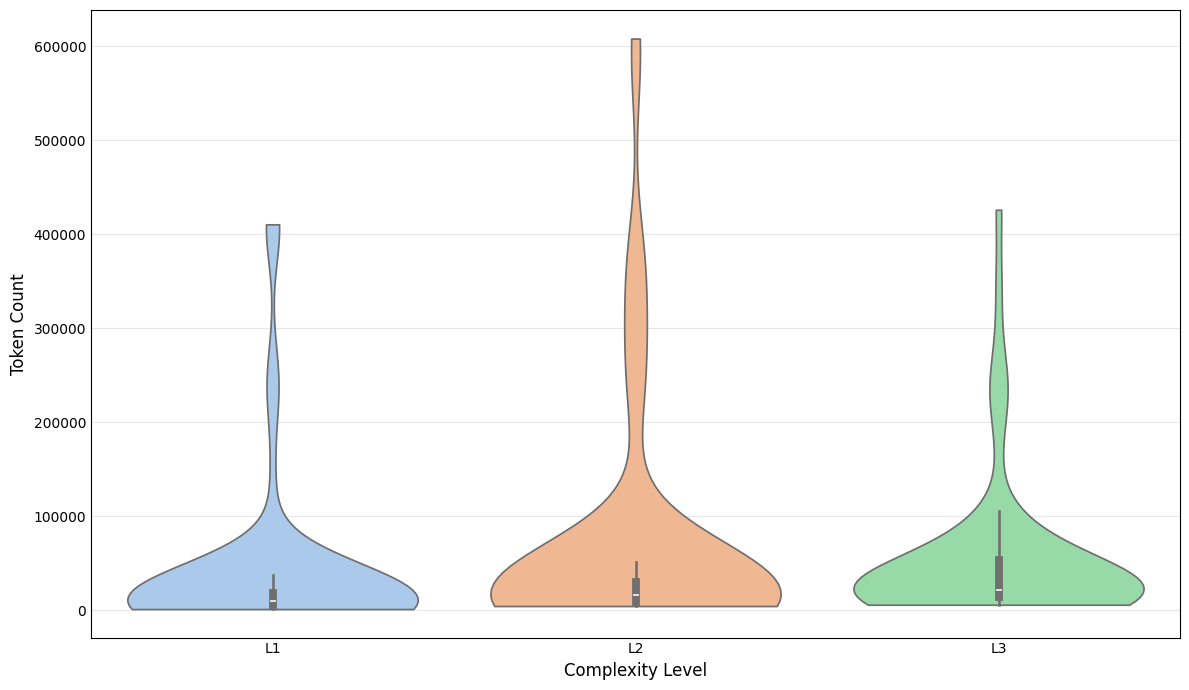

In [685]:
fig, ax = plt.subplots(figsize=(12, 7))

sns.violinplot(
    x="complexity", y="all_tokens", data=df_filtered, ax=ax, palette="pastel", cut=0
)

ax.set_xlabel("Complexity Level", fontsize=12)
ax.set_ylabel("Token Count", fontsize=12)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

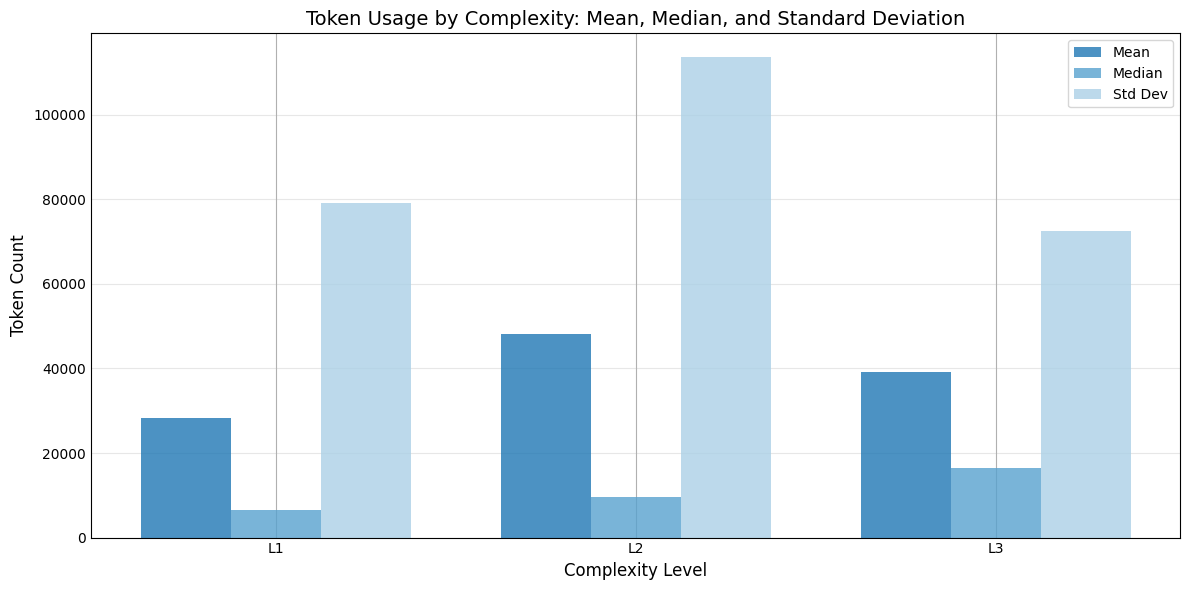

In [686]:

fig, ax = plt.subplots(figsize=(12, 6))

complexities = all_tokens_summary.index.tolist()
x_pos = np.arange(len(complexities))
bar_width = 0.25

# Extract data for each statistic
means = all_tokens_summary['mean'].values
medians = all_tokens_summary['median'].values
stds = all_tokens_summary['std'].values

# Create bars
ax.bar(x_pos - bar_width, means, bar_width, label='Mean', alpha=0.8)
ax.bar(x_pos, medians, bar_width, label='Median', alpha=0.8)
ax.bar(x_pos + bar_width, stds, bar_width, label='Std Dev', alpha=0.8)

# Customize plot
ax.set_xlabel('Complexity Level', fontsize=12)
ax.set_ylabel('Token Count', fontsize=12)
ax.set_title('Token Usage by Complexity: Mean, Median, and Standard Deviation', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(complexities)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [687]:
all_time_summary = (
    df_A_gemini.groupby("complexity")["duration_seconds"]
    .agg(["mean", "median", "std"])
    .round(4)
)

display(all_time_summary)

all_time_summary_large = (
    df_A_gemini.groupby(["complexity", "condition"])["duration_seconds"]
    .agg(aggs)
    .round(4)
)

display(all_time_summary_large)

,mean,median,std
complexity,,,
L1,64.3472,7.8405,195.3080
L2,108.9002,13.1195,285.7027
L3,77.9402,24.5605,174.7378


mean       std   median
complexity condition                             
L1         C1           0.0021    0.0015    0.002
           C2           7.4182    4.5111    6.093
           C3           9.7285    3.8683    9.607
           C4         240.2400  338.0681   63.381
L2         C1           0.0032    0.0015    0.003
           C2          13.3283    4.7923   11.698
           C3          20.1972   11.6207   14.686
           C4         402.0720  465.7843   91.113
L3         C1           0.0041    0.0024    0.003
           C2          24.0260   10.7894   22.678
           C3          27.9142    9.1044   25.191
           C4         259.8167  281.6581  127.910

In [688]:
all_time_summary["Mean (SD)"] = all_time_summary.apply(
    lambda row: f"{row['mean']:.4f} ({row['std']:.4f})", axis=1
)

all_time_summary = all_time_summary[["Mean (SD)", "median"]]

time_final_table = all_time_summary.unstack(level="complexity").to_frame()
time_final_table.columns.names = ["Complexity"]
time_final_table.index.name = "Metric"
time_final_table.columns.names = [None]
time_final_table.index.name = None

time_final_table = time_final_table.rename(
    index={"median": "Mdn", "Mean (SD)": "M (SD)"}
)

time_final_table.to_excel("./tables/time-to-completion_summary.xlsx", index=True)
display(time_final_table)

0
       complexity                     
M (SD) L1           64.3472 (195.3080)
       L2          108.9002 (285.7027)
       L3           77.9402 (174.7378)
Mdn    L1                       7.8405
       L2                      13.1195
       L3                      24.5605

In [689]:
plot_df = all_time_summary.reset_index().copy()
plot_df["mean"] = plot_df["mean"].str.extract(r"^([0-9\.]+)").astype(float)

pivot_mean = plot_df.pivot(index="condition", columns="complexity", values="mean")

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(pivot_mean.index))
width = 0.2

for i, complexity in enumerate(pivot_mean.columns):
    ax.bar(x + i * width, pivot_mean[complexity], width, label=complexity)

ax.set_xticks(x + width * (len(pivot_mean.columns) - 1) / 2)
ax.set_xticklabels(pivot_mean.index)
ax.set_xlabel("Condition")
ax.set_ylabel("Mean Token Count")
ax.legend(title="Complexity")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

KeyError: 'mean'

## statistischer Hypothesentest mit ANOVA

In [ ]:
from statsmodels.formula.api import ols
import scipy.stats as stats

model = ols("f1_exact ~ C(condition) * C(complexity)", data=df_A_gemini[df_A_gemini['f1_exact'].notnull()]).fit()
residuals = model.resid

# shapiro-wilk Test
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Shapiro-Wilk-Test auf Normalverteilung: p-Wert = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("-> Residuen sind annähernd normalverteilt (p > 0.05).")
else:
    print("-> WARNUNG: Normalverteilung verletzt (p <= 0.05).")

Shapiro-Wilk-Test auf Normalverteilung: p-Wert = 0.0000
-> WARNUNG: Normalverteilung verletzt (p <= 0.05).


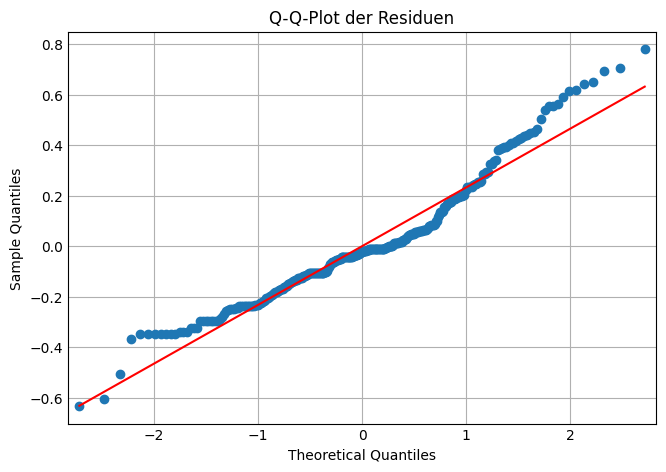

In [ ]:
import statsmodels.api as sm

fig, ax = plt.subplots(figsize=(6, 4))
sm.qqplot(residuals, line="s", ax=ax)
ax.set_title("Q-Q-Plot der Residuen")
plt.show()

In [ ]:
groups = [
    group["f1_exact"].values
    for name, group in df_A_gemini.groupby(["condition", "complexity"])
]
levene_stat, levene_p = stats.levene(*groups)

print(f"\nLevene-Test auf Varianzhomogenität: p-Wert = {levene_p:.4f}")
if levene_p > 0.05:
    print("-> Varianzen sind homogen (p > 0.05).")
else:
    print("-> WARNUNG: Varianzhomogenität verletzt (p <= 0.05).")


Levene-Test auf Varianzhomogenität: p-Wert = 0.0000
-> WARNUNG: Varianzhomogenität verletzt (p <= 0.05).


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "f1_exact ~ C(condition) * C(complexity)",
    data=df_A_gemini[df_A_gemini["f1_exact"].notnull()],
).fit()

anova_table_robust = sm.stats.anova_lm(model, typ=2, robust="HC3")

print("Robuste zweifaktorielle ANOVA (Typ II mit HC3-Korrektur):")
display(anova_table_robust)

Robuste zweifaktorielle ANOVA (Typ II mit HC3-Korrektur):


,sum_sq,df,F,PR(>F)
C(condition),11.748714,3.0,69.338118,8.860744e-34
C(complexity),12.188667,2.0,107.901926,1.063811e-35
C(condition):C(complexity),1.740914,6.0,5.137230,4.925537e-05
Residual,16.266328,288.0,NaN,NaN


In [ ]:
df_llm_only = df_A_gemini[
    (df_A_gemini["condition"] != "C1") & (df_A_gemini["f1_fuzzy"].notnull())
]

model_llm = ols("f1_exact ~ C(condition) * C(complexity)", data=df_llm_only).fit()
residuals_llm = model_llm.resid

shapiro_stat, shapiro_p = stats.shapiro(residuals_llm)
print(f"Shapiro-Wilk-Test (nur KI-Systeme): p-Wert = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("-> Residuen sind normalverteilt (p > 0.05).")
else:
    print("-> WARNUNG: Normalverteilung verletzt (p <= 0.05).")

Shapiro-Wilk-Test (nur KI-Systeme): p-Wert = 0.0000
-> WARNUNG: Normalverteilung verletzt (p <= 0.05).


In [ ]:
groups_llm = [
    group["f1_fuzzy"].values
    for name, group in df_llm_only.groupby(["condition", "complexity"])
]
levene_stat, levene_p = stats.levene(*groups_llm)

print(f"\nLevene-Test (nur KI-Systeme): p-Wert = {levene_p:.4f}")
if levene_p > 0.05:
    print("-> Varianzen sind homogen (p > 0.05).")
else:
    print("-> WARNUNG: Varianzhomogenität verletzt (p <= 0.05).")


Levene-Test (nur KI-Systeme): p-Wert = 0.0002
-> WARNUNG: Varianzhomogenität verletzt (p <= 0.05).


In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "f1_exact ~ C(condition) * C(complexity)",
    data=df_A_gemini[(df_A_gemini["condition"] != "C1") & (df_A_gemini["f1_fuzzy"].notnull()) ],
).fit()

anova_table_robust_llms = sm.stats.anova_lm(model, typ=2, robust="HC3")

print("Robuste zweifaktorielle ANOVA (Typ II mit HC3-Korrektur):")
display(anova_table_robust_llms)

Robuste zweifaktorielle ANOVA (Typ II mit HC3-Korrektur):


,sum_sq,df,F,PR(>F)
C(condition),0.090224,2.0,0.622015,5.378203e-01
C(complexity),12.940104,2.0,89.210996,5.717472e-29
C(condition):C(complexity),0.323522,4.0,1.115206,3.502347e-01
Residual,15.665459,216.0,NaN,NaN


## Business Impact Analyse